# A geodesic combing of $\mathbb{Z}^2$

Use $G=\langle a,b\mid ab=ba\rangle$ with $S=\{a,a^{-1},b,b^{-1}\}$. The combing chooses the normal form $a^m b^n$ for each $(m,n)\in\mathbb{Z}^2$, reading negative powers as repeated inverse letters.

This notebook gives the labeled directed graph, its adjacency matrix $M$, and its strongly connected component quotient. The initial state is $v_0$, and **all five states are accepting**. The empty path represents $(0,0)$. Uppercase `A` and `B` denote inverse letters in code and appear with inverse exponents in the figures.

In [68]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path
from matplotlib.transforms import Affine2D
from IPython.display import display, Math

%matplotlib inline
plt.ioff()
plt.rcParams.update({'figure.dpi': 130, 'font.size': 12})
np.set_printoptions(linewidth=100)

## 1. Labeled transitions

Reading a letter $s$ leads to $v_s$. Each noninitial state has a loop labeled by its own letter. The only edges between distinct noninitial states go from $v_a$ or $v_{a^{-1}}$ to $v_b$ or $v_{b^{-1}}$.

| State | Allowed next letters |
|:--|:--|
| $v_0$ | $a,a^{-1},b,b^{-1}$ |
| $v_a$ | $a,b,b^{-1}$ |
| $v_{a^{-1}}$ | $a^{-1},b,b^{-1}$ |
| $v_b$ | $b$ |
| $v_{b^{-1}}$ | $b^{-1}$ |

In [69]:
letters = ('a', 'A', 'b', 'B')
states = ['v0', 'v_a', 'v_A', 'v_b', 'v_B']
idx = {v: i for i, v in enumerate(states)}
allowed = {'v0': 'aAbB', 'v_a': 'abB', 'v_A': 'AbB', 'v_b': 'b', 'v_B': 'B'}
transitions = {v: [(s, 'v_' + s) for s in word] for v, word in allowed.items()}
G = nx.DiGraph()
G.add_nodes_from(states)
for source, outgoing in transitions.items():
    for letter, target in outgoing:
        G.add_edge(source, target, label=letter)

letter_tex = {'a': 'a', 'A': r'a^{-1}', 'b': 'b', 'B': r'b^{-1}'}
state_tex = {'v0': r'v_0', **{'v_' + s: 'v_{' + t + '}' for s,t in letter_tex.items()}}
print(f'{G.number_of_nodes()} states; {G.number_of_edges()} labeled edges, including four loops.')

5 states; 12 labeled edges, including four loops.


## 2. The directed graph $\mathcal{G}$

The layout places $v_0$ at the center, $v_a$ above, $v_{a^{-1}}$ below, $v_b$ to the right, and $v_{b^{-1}}$ to the left. Double circles mark accepting states. The small arrow labeled “start” marks the initial state; it is not a graph edge.

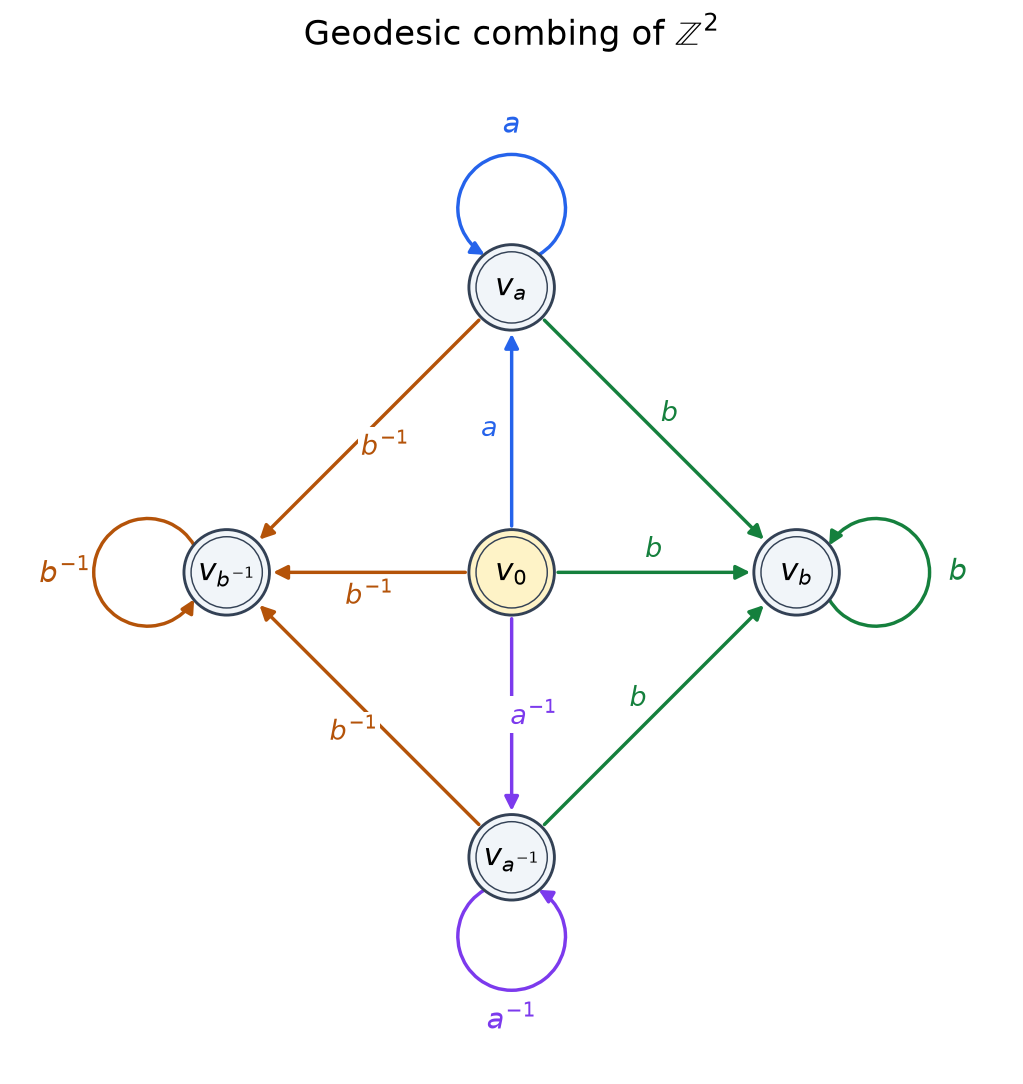

In [70]:
pos = {'v0': (0,0), 'v_a': (0,1.8), 'v_A': (0,-1.8),
       'v_b': (1.8,0), 'v_B': (-1.8,0)}
palette = {'a':'#2563eb', 'A':'#7c3aed', 'b':'#15803d', 'B':'#b45309'}
fig, ax = plt.subplots(figsize=(8.5,8.5))
node_radius = 0.27

# Straight non-loop edges, with labels clear of each arrow.
for u,v,data in G.edges(data=True):
    if u == v:
        continue
    p,q = np.array(pos[u],float),np.array(pos[v],float)
    direction = (q-p) / np.linalg.norm(q-p)
    ax.add_patch(FancyArrowPatch(p + node_radius*direction, q - node_radius*direction,
                               arrowstyle='-|>', mutation_scale=16, lw=1.9,
                               color=palette[data['label']], zorder=1))
    midpoint = (p+q)/2
    normal = np.array([-direction[1], direction[0]])
    label_pos = midpoint + 0.14*normal
    ax.text(*label_pos, '$' + letter_tex[data['label']] + '$',
            ha='center', va='center', fontsize=15, color=palette[data['label']],
            bbox=dict(fc='white', ec='none', pad=1.5), zorder=4)

# Circular 300-degree arcs point outward from the cardinal states.
for s in letters:
    p = np.array(pos['v_' + s],float)
    outward = p / np.linalg.norm(p)
    angle = np.arctan2(outward[1],outward[0])
    center = p + 0.50*outward
    arc = Path.arc(-150,150)
    arc = Affine2D().scale(0.34).rotate(angle).translate(*center).transform_path(arc)
    ax.add_patch(FancyArrowPatch(path=arc, arrowstyle='-|>', mutation_scale=15,
                               lw=1.9, color=palette[s], zorder=2))
    ax.text(*(p + 1.02*outward), '$' + letter_tex[s] + '$',
            ha='center', va='center', fontsize=16, color=palette[s])

for v,p in pos.items():
    fill = '#fef3c7' if v == 'v0' else '#f1f5f9'
    ax.add_patch(Circle(p,node_radius,fc=fill,ec='#334155',lw=1.6,zorder=5))
    ax.add_patch(Circle(p,node_radius-0.045,fill=False,ec='#334155',lw=0.8,zorder=6))
    ax.text(*p,'$' + state_tex[v] + '$',ha='center',va='center',fontsize=17,zorder=7)
    # ax.annotate('start',xy=(-0.20,-0.20),xytext=(-0.72,-0.73),ha='center',fontsize=11,color='#475569',arrowprops=dict(arrowstyle='-|>',lw=1.2,color='#475569'))
ax.set(xlim=(-3.15,3.15),ylim=(-3.15,3.15),aspect='equal')
ax.set_title(r'Geodesic combing of $\mathbb{Z}^2$',fontsize=19,pad=16)
ax.axis('off')
plt.tight_layout()
fig.savefig("z2_automaton.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Adjacency matrix $M$

In the fixed order $(v_0,v_a,v_{a^{-1}},v_b,v_{b^{-1}})$, the entry $M_{ij}$ is $1$ exactly when an edge goes from state $i$ to state $j$. The initial state has no incoming edges, so the first column is zero. This is the adjacency matrix, not a stochastic matrix.

In [71]:
M = nx.to_numpy_array(G,nodelist=states,dtype=int)
expected_M = np.array([
    [0,1,1,1,1],
    [0,1,0,1,1],
    [0,0,1,1,1],
    [0,0,0,1,0],
    [0,0,0,0,1],
])
assert np.array_equal(M,expected_M)
rows = [' & '.join(map(str,row)) for row in M]
display(Math(r'M=\begin{pmatrix}' + r'\\'.join(rows) + r'\end{pmatrix}'))

<IPython.core.display.Math object>

### Spectral radius and the Cesàro limits

Use the definitions in [the manuscript](../ordered_frequency_git/sections/geodesic_combings.tex), including the $k=0$ term and the denominator $n$:
$$
r_n=\frac1n\sum_{k=0}^{n}\lambda^{-k}M^k\mathbf1,
\qquad
\ell_n=\frac1n\sum_{k=0}^{n}\lambda^{-k}(M^T)^k\mathbf e_0.
$$
The following cell computes the spectral radius $\lambda$, both finite averages, and their coordinatewise limits **exactly**. All vectors use the state order $(v_0,v_a,v_{a^{-1}},v_b,v_{b^{-1}})$.

Here $\lambda=1$, while both averages diverge as vectors in $\mathbb R^5$: the first three coordinates of $r_n$ and the last two coordinates of $\ell_n$ tend to $+\infty$. The displayed infinities describe extended-real coordinate limits; they do not define finite Perron–Frobenius vectors $r$ and $\ell$.

The eigenvalue $1$ has algebraic multiplicity four and geometric multiplicity three, so it has a nontrivial Jordan block. Consequently $M^k$ grows linearly despite its spectral radius being one. In particular, $(M^k\mathbf1)_0=4k$ for $k\geq1$, matching the size of a lattice sphere. This graph does not satisfy the manuscript's almost-semisimplicity hypothesis, so its convergence statement does not apply. Eigenvectors still exist, but they are different objects from the specified limits.


In [ ]:
import sympy as sp
from IPython.display import display, Math

M_exact = sp.Matrix(M)
pf_spectrum = M_exact.eigenvals()
lam = max(sp.Abs(value) for value in pf_spectrum)
k, n = sp.symbols('k n', integer=True, positive=True)
ones = sp.ones(len(states), 1)
e0 = sp.eye(len(states))[:, states.index('v0')]

# k is positive: keep the k=0 term separate in the manuscript's sums.
M_power = (M_exact ** k).applyfunc(sp.simplify)
right_power = (M_power * ones).applyfunc(sp.simplify)
left_power = (M_power.T * e0).applyfunc(sp.simplify)
r_n = ((ones + right_power.applyfunc(
    lambda value: sp.summation(value / lam**k, (k, 1, n)))) / n).applyfunc(sp.simplify)
l_n = ((e0 + left_power.applyfunc(
    lambda value: sp.summation(value / lam**k, (k, 1, n)))) / n).applyfunc(sp.simplify)

# These are coordinatewise extended-real limits, not finite PF vectors r,l.
r_limit = r_n.applyfunc(lambda value: sp.limit(value, n, sp.oo))
l_limit = l_n.applyfunc(lambda value: sp.limit(value, n, sp.oo))
algebraic_multiplicity = pf_spectrum[lam]
geometric_multiplicity = len((M_exact - lam * sp.eye(len(states))).nullspace())

# Verify the symbolic power formula by its base case and recurrence.
assert M_power.subs(k, 1) == M_exact
assert (M_exact * M_power - M_power.subs(k, k + 1)).applyfunc(sp.simplify) == sp.zeros(len(states))
assert lam == 1 and (algebraic_multiplicity, geometric_multiplicity) == (4, 3)
assert r_n.subs(n, 1) == ones + M_exact * ones
assert l_n.subs(n, 1) == e0 + M_exact.T * e0
assert r_limit == sp.Matrix([sp.oo, sp.oo, sp.oo, 1, 1])
assert l_limit == sp.Matrix([0, 1, 1, sp.oo, sp.oo])

display(Math(r'\lambda=' + sp.latex(lam)
             + r'\qquad\operatorname{spec}(M)=\{0,1,1,1,1\}'))
display(Math(r'M^k\mathbf1=' + sp.latex(right_power)
             + r'\qquad(M^T)^k\mathbf e_0=' + sp.latex(left_power)
             + r'\quad(k\geq1)'))
display(Math(r'r_n=\frac1n\sum_{k=0}^{n}\lambda^{-k}M^k\mathbf1='
             + sp.latex(r_n)))
display(Math(r'\ell_n=\frac1n\sum_{k=0}^{n}\lambda^{-k}(M^T)^k\mathbf e_0='
             + sp.latex(l_n)))
display(Math(r'\lim_{n\to\infty}r_n=' + sp.latex(r_limit)
             + r'\qquad\lim_{n\to\infty}\ell_n=' + sp.latex(l_limit)))
print('Both Cesaro sequences diverge as finite vectors; some coordinates tend to +infinity.')
print('Eigenvalue 1: algebraic multiplicity =', algebraic_multiplicity,
      '; geometric multiplicity =', geometric_multiplicity)
print('Thus finite r and l are not defined by these limits for this graph.')


## 4. Strongly connected component quotient

Each state forms its own strongly connected component. Once a path leaves an $a$ state for a $b$ state, it cannot return. The loops make the four noninitial singleton components cyclic, but do not connect distinct states mutually.

Write $C_0=\{v_0\}$ and $C_s=\{v_s\}$ for $s\in S$. The quotient removes the four loops and retains the eight edges between distinct components, including the direct edges $C_0\to C_b$ and $C_0\to C_{b^{-1}}$. These are retained even though two-step paths with the same endpoints also exist. Thus this is the condensation graph, not its transitive reduction. Generator labels are omitted from the quotient.

In [ ]:
components = sorted(nx.strongly_connected_components(G),key=lambda comp:min(idx[v] for v in comp))
assert components == [{v} for v in states]
Q = nx.condensation(G,scc=components)
assert Q.number_of_nodes() == 5 and Q.number_of_edges() == 8
Q_adjacency = nx.to_numpy_array(Q,nodelist=range(5),dtype=int)
assert np.array_equal(Q_adjacency,M - np.diag(np.diag(M)))

fig, ax = plt.subplots(figsize=(8.5,6.8))
for i,j in Q.edges():
    p,q = np.array(pos[states[i]],float),np.array(pos[states[j]],float)
    unit = (q-p) / np.linalg.norm(q-p)
    ax.add_patch(FancyArrowPatch(p+0.39*unit,q-0.39*unit,arrowstyle='-|>',
                               mutation_scale=17,lw=1.7,color='#475569'))
for i,v in enumerate(states):
    label = r'C_0' if v == 'v0' else 'C_{' + letter_tex[v[2:]] + '}'
    ax.text(*pos[v],'$' + label + '$',ha='center',va='center',fontsize=18,
            bbox=dict(boxstyle='round,pad=0.55',fc='#fef3c7' if i==0 else '#dbeafe',
                      ec='#92400e' if i==0 else '#1e40af',lw=1.5))
ax.set(xlim=(-2.65,2.65),ylim=(-2.4,2.4),aspect='equal')
ax.set_title(r'Component quotient $C(\mathcal{G})$',fontsize=18,pad=16)
ax.axis('off')
plt.tight_layout()
fig.savefig("z2_component_quotient.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Why this is a geodesic combing

An accepted word consists of a constant-sign $a$ run followed by a constant-sign $b$ run, with either run allowed to be empty. Hence the accepted words are exactly the normal forms $a^m b^n$. Distinct pairs $(m,n)$ give distinct group elements, and every pair occurs, so evaluation of paths starting at $v_0$ is bijective.

The word $a^m b^n$ has length $|m|+|n|$. Every generator changes one coordinate by one, so any word representing $(m,n)$ has length at least $|m|+|n|$. Each chosen word is therefore geodesic. Prefixes are again chosen normal forms, giving a prefix-closed regular language. Every state is reachable, so words read along arbitrary finite paths are also geodesic: they are suffixes of geodesic paths from $v_0$.

This combing selects one representative per element rather than every geodesic word; for example, $ba$ is geodesic but is represented by $ab$ in the combing.

In [ ]:
# Finite check against independent lattice spheres, rather than graph counts alone.
steps = {'a': (1,0), 'A': (-1,0), 'b': (0,1), 'B': (0,-1)}
paths = [('v0',(0,0))]
counts = []
max_length = 10
for n in range(max_length+1):
    endpoints = [point for _,point in paths]
    sphere = {(x,y) for x in range(-n,n+1) for y in range(-n,n+1) if abs(x)+abs(y)==n}
    assert len(endpoints) == len(set(endpoints)), f'Duplicate representative at length {n}'
    assert set(endpoints) == sphere, f'Incorrect sphere at length {n}'
    counts.append(len(endpoints))
    paths = [(target,(point[0]+steps[s][0],point[1]+steps[s][1]))
             for state,point in paths for s,target in transitions[state]]
assert counts == [1] + [4*n for n in range(1,max_length+1)]
print('Verified exact adjacency matrix, five singleton SCCs, and eight quotient edges.')
print(f'Bijective geodesic paths verified through length {max_length}.')
print(f'Sphere sizes, n = 0,...,{max_length}:',counts)

## 6. Combing rays in the lattice

Identify $a=(1,0)$ and $b=(0,1)$. This plot uses horizontal $a$ motion and vertical $b$ motion; the earlier automaton diagram's positions indicate states, not lattice coordinates.

Every infinite path from $v_0$ either stays on the $a$-axis forever, or follows a finite $a$ run and then continues forever in one $b$ direction. Thus the rays are
$$
a^\infty,\quad (a^{-1})^\infty,\quad
 a^m b^\infty,\quad a^m(b^{-1})^\infty\qquad(m\in\mathbb Z).
$$
Here a negative $m$ means $|m|$ copies of $a^{-1}$, and $m=0$ gives the vertical rays from the identity.

The plot shows their union inside the word-metric ball $|m|+|n|\leq R$, where $R$ is set by `ray_depth`. Grey arrows follow the combing tree outward from the identity; faint edges belong to the surrounding Cayley graph. Two colored examples show an initial horizontal segment followed by an infinite vertical ray. Boundary arrows indicate continuation beyond the displayed ball. Change `ray_depth` to resize the view.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# Increase this to show a larger word-metric ball in the lattice.
ray_depth = 7
assert isinstance(ray_depth, int) and ray_depth >= 4
ray_steps = {'a': (1, 0), 'A': (-1, 0), 'b': (0, 1), 'B': (0, -1)}

# Follow the actual automaton, retaining its state at each lattice point.
frontier = [('v0', (0, 0))]
vertices = {(0, 0)}
combing_edges = []
for depth in range(ray_depth):
    next_frontier = []
    for state, point in frontier:
        for letter, target in transitions[state]:
            dx, dy = ray_steps[letter]
            endpoint = (point[0] + dx, point[1] + dy)
            assert endpoint not in vertices, 'The combing must give unique paths.'
            vertices.add(endpoint)
            combing_edges.append((point, endpoint))
            next_frontier.append((target, endpoint))
    frontier = next_frontier
assert vertices == {(m, n) for m in range(-ray_depth, ray_depth + 1)
                    for n in range(-ray_depth, ray_depth + 1)
                    if abs(m) + abs(n) <= ray_depth}

# Faint edges show the surrounding Cayley graph; arrows show the combing tree.
ambient_edges = [(p, (p[0] + dx, p[1] + dy)) for p in sorted(vertices)
                 for dx, dy in [(1, 0), (0, 1)]
                 if (p[0] + dx, p[1] + dy) in vertices]
fig, ax = plt.subplots(figsize=(10, 9))
ax.add_collection(LineCollection(ambient_edges, colors='#e2e8f0', linewidths=1, zorder=0))
ax.add_collection(LineCollection(combing_edges, colors='#64748b', linewidths=1.7, zorder=1))
edge_starts = np.array([p for p, q in combing_edges], dtype=float)
edge_vectors = np.array([(q[0] - p[0], q[1] - p[1]) for p, q in combing_edges])
arrow_starts = edge_starts + 0.35 * edge_vectors
ax.quiver(arrow_starts[:, 0], arrow_starts[:, 1],
          0.32 * edge_vectors[:, 0], 0.32 * edge_vectors[:, 1],
          angles='xy', scale_units='xy', scale=1, width=0.003,
          headwidth=4.5, headlength=5, color='#64748b', zorder=2)
points = np.array(sorted(vertices))
ax.scatter(points[:, 0], points[:, 1], s=9, color='#94a3b8', zorder=3)

# Two highlighted examples, validated against the automaton.
example_rays = [(3, 1, '#15803d', r'$a^3 b^\infty$'),
                (-2, -1, '#7c3aed', r'$a^{-2}(b^{-1})^\infty$')]
ray_legend = []
for turn_at, vertical_sign, color, label in example_rays:
    word = ('a' if turn_at >= 0 else 'A') * abs(turn_at)
    word += ('b' if vertical_sign > 0 else 'B') * (ray_depth - abs(turn_at))
    state, point = 'v0', (0, 0)
    path = [point]
    for letter in word:
        state = dict(transitions[state])[letter]
        dx, dy = ray_steps[letter]
        point = (point[0] + dx, point[1] + dy)
        path.append(point)
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], color=color, lw=3.6, zorder=4)
    endpoint = path[-1].astype(float)
    ax.annotate('', xy=endpoint + [0, 0.52 * vertical_sign], xytext=endpoint,
                arrowprops=dict(arrowstyle='-|>', color=color, lw=2.5, mutation_scale=16))
    ray_legend.append(Line2D([0], [0], color=color, lw=3, label=label))

# Outward arrows mark that the other boundary paths also continue infinitely.
for m, n in sorted(vertices):
    if abs(m) + abs(n) != ray_depth or (m, n) in [(3, ray_depth - 3), (-2, -(ray_depth - 2))]:
        continue
    direction = np.array([0, np.sign(n)]) if n else np.array([np.sign(m), 0])
    endpoint = np.array([m, n], dtype=float)
    ax.annotate('', xy=endpoint + 0.4 * direction, xytext=endpoint,
                arrowprops=dict(arrowstyle='-|>', color='#64748b', lw=1.4, mutation_scale=11))
ax.scatter([0], [0], s=150, marker='*', color='red', zorder=6)
ax.annotate('$id$', (0, 0), xytext=(9, -17), textcoords='offset points', fontsize=10, color = 'red')
ax.set(xlim=(-ray_depth - 0.8, ray_depth + 0.8),
       ylim=(-ray_depth - 0.8, ray_depth + 0.8), aspect='equal',
       xlabel=r'$m$ (exponent of $a$)', ylabel=r'$n$ (exponent of $b$)')
ax.set_xticks(range(-ray_depth, ray_depth + 1))
ax.set_yticks(range(-ray_depth, ray_depth + 1))
ax.set_title(r'Combing rays in $\mathbb{Z}^2$: horizontal first ($a$), then vertical ($b$)', pad=16)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0, labelsize=9)
ax.legend(handles=[Line2D([0], [0], color='#e2e8f0', lw=2, label='Other Cayley graph edges'),
                   Line2D([0], [0], color='#64748b', lw=2, label='Combing tree')] + ray_legend,
          loc='upper left', frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig("z2_combing_rays.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. The radius-seven Cayley ball

The vertices are $(m,n)$ with $|m|+|n|\leq7$, using $a=(1,0)$ and $b=(0,1)$ as in the combing-rays picture. Draw every Cayley edge whose endpoints lie in this ball, all dashed grey, with the identity marked by a red star. This is the full Cayley graph on the ball, rather than only the combing tree.

Set `z2_cayley_radius` to change the radius for both new pictures. This cell constructs its own graph and does not require the earlier plotting cells.


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

z2_cayley_radius = 7
assert isinstance(z2_cayley_radius, int) and z2_cayley_radius >= 1
z2_ball_vertices = [(m, n) for m in range(-z2_cayley_radius, z2_cayley_radius + 1)
                    for n in range(-z2_cayley_radius, z2_cayley_radius + 1)
                    if abs(m) + abs(n) <= z2_cayley_radius]
z2_cayley_ball = nx.Graph()
z2_cayley_ball.add_nodes_from(z2_ball_vertices)
for m, n in z2_ball_vertices:
    for generator, endpoint in [('a', (m + 1, n)), ('b', (m, n + 1))]:
        if endpoint in z2_cayley_ball:
            z2_cayley_ball.add_edge((m, n), endpoint, generator=generator, kind='cayley')
assert len(z2_cayley_ball) == 1 + 2 * z2_cayley_radius * (z2_cayley_radius + 1)
assert z2_cayley_ball.number_of_edges() == 4 * z2_cayley_radius**2
z2_cayley_pos = {point: np.array(point, dtype=float) for point in z2_cayley_ball}
z2_gray = '#94a3b8'
z2_cone_red = '#dc2626'

def draw_z2_cayley_background(axis):
    """Shared lattice and framing for direct comparison of the two pictures."""
    segments = [(z2_cayley_pos[g], z2_cayley_pos[h]) for g, h in z2_cayley_ball.edges()]
    axis.add_collection(LineCollection(segments, colors=z2_gray, linestyles='dashed',
                                       linewidths=1.05, zorder=1))
    points = np.array(z2_ball_vertices)
    axis.scatter(points[:, 0], points[:, 1], s=20, facecolors='white',
                  edgecolors='#64748b', lw=0.7, zorder=4)
    axis.scatter([0], [0], marker='*', s=150, color='red', zorder=6)
    axis.annotate('$id$', (0, 0), xytext=(-18, -17), textcoords='offset points',
                   fontsize=10, color='red')
    axis.set(xlim=(-z2_cayley_radius - 0.8, z2_cayley_radius + 0.9),
             ylim=(-z2_cayley_radius - 0.8, z2_cayley_radius + 1.5), aspect='equal',
             xlabel=r'$m$ (exponent of $a$)', ylabel=r'$n$ (exponent of $b$)')
    axis.set_xticks(range(-z2_cayley_radius, z2_cayley_radius + 1))
    axis.set_yticks(range(-z2_cayley_radius, z2_cayley_radius + 1))
    axis.tick_params(length=0, labelsize=9)
    for spine in axis.spines.values():
        spine.set_visible(False)

fig_z2_cayley, ax_z2_cayley = plt.subplots(figsize=(10, 10))
draw_z2_cayley_background(ax_z2_cayley)
ax_z2_cayley.set_title(r'Cayley graph of $\mathbb{Z}^2$'
                       + f'\nRadius {z2_cayley_radius}: {len(z2_cayley_ball)} vertices, '
                       + f'{z2_cayley_ball.number_of_edges()} edges', pad=16)
ax_z2_cayley.legend(handles=[Line2D([0], [0], color=z2_gray, ls='--', lw=1.5,
                                   label='All Cayley edges')], loc='upper left', frameon=False)
fig_z2_cayley.tight_layout()
fig_z2_cayley.savefig("z2_cayley_ball.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Coning off the cosets of $\langle b\rangle$

The left cosets are $a^m\langle b\rangle=\{(m,n):n\in\mathbb Z\}$, so each vertical column gets one red cone vertex. Join that cone to every visible vertex in its column by a red edge. All original Cayley edges remain dashed grey, and both pictures use the same group-vertex positions and axes.

At radius seven there are 15 cosets meeting the ball, including the two columns consisting of a single boundary vertex. This is a finite portion of the coned-off graph over the original Cayley ball, not a ball in the coned-off metric. In the full graph each cone is joined to the entire infinite column. The horizontal offset of cone vertices is only for visibility.

Run the preceding cell first; this cell creates `z2_coned_ball` without changing `z2_cayley_ball`.


In [ ]:
# Left cosets a^m<b> are vertical columns, indexed by the a-coordinate m.
z2_b_cosets = {m: [g for g in z2_ball_vertices if g[0] == m]
               for m in range(-z2_cayley_radius, z2_cayley_radius + 1)}
z2_coned_ball = z2_cayley_ball.copy()
nx.set_node_attributes(z2_coned_ball, 'group', 'kind')
z2_cone_vertices = {m: ('cone', m) for m in z2_b_cosets}
z2_cone_positions = {}
for m, members in z2_b_cosets.items():
    cone = z2_cone_vertices[m]
    z2_coned_ball.add_node(cone, kind='cone', coset=m)
    z2_coned_ball.add_edges_from((cone, g, {'kind': 'cone'}) for g in members)
    # A small sideways offset separates cone edges from the vertical Cayley edges.
    z2_cone_positions[m] = np.array([m + 0.80, max(g[1] for g in members) + 0.8])
z2_coned_pos = dict(z2_cayley_pos)
z2_coned_pos.update({z2_cone_vertices[m]: p for m, p in z2_cone_positions.items()})
assert len(z2_cone_vertices) == 2 * z2_cayley_radius + 1
assert z2_coned_ball.number_of_edges() == z2_cayley_ball.number_of_edges() + len(z2_cayley_ball)
assert all(set(z2_coned_ball.neighbors(z2_cone_vertices[m])) == set(members)
           for m, members in z2_b_cosets.items())

fig_z2_coned, ax_z2_coned = plt.subplots(figsize=(10, 10))
draw_z2_cayley_background(ax_z2_coned)
z2_cone_segments = [(z2_cone_positions[m], z2_cayley_pos[g])
                    for m, members in z2_b_cosets.items() for g in members]
ax_z2_coned.add_collection(LineCollection(z2_cone_segments, colors=z2_cone_red,
                                         linewidths=0.9, alpha=0.8, zorder=2))
z2_cone_xy = np.array(list(z2_cone_positions.values()))
ax_z2_coned.scatter(z2_cone_xy[:, 0], z2_cone_xy[:, 1], s=55, marker='D',
                    facecolors=z2_cone_red, edgecolors='white', lw=0.7, zorder=5)
ax_z2_coned.annotate(r'$v_{\langle b\rangle}$', z2_cone_positions[0],
                     xytext=(10, 4), textcoords='offset points', fontsize=11, color=z2_cone_red)
ax_z2_coned.set_title(r'Coned-off Cayley graph of $\mathbb{Z}^2$ relative to $\langle b\rangle$'
                      + f'\nSame radius-{z2_cayley_radius} ball; one cone per vertical column', pad=16)
ax_z2_coned.legend(handles=[
    Line2D([0], [0], color=z2_gray, ls='--', lw=1.5, label='All Cayley edges'),
    Line2D([0], [0], color=z2_cone_red, lw=1.5, label='Cone edges'),
    Line2D([0], [0], color='none', marker='D', markerfacecolor=z2_cone_red,
           markeredgecolor='white', markersize=7, label=r'Cone for $a^m\langle b\rangle$')],
    loc='upper left', frameon=False, fontsize=10)
fig_z2_coned.tight_layout()
fig_z2_coned.savefig("z2_coned_cayley_ball.png", dpi=300, bbox_inches="tight")
plt.show()
print(f'{len(z2_cayley_ball)} group vertices and {z2_cayley_ball.number_of_edges()} Cayley edges; '
      f'{len(z2_cone_vertices)} cone vertices and {len(z2_cone_segments)} cone edges added.')
